# Solved Exam Notebook — 5th of January 2023

Course: **1MS041 Introduction to Data Science / Introduktion till dataanalys**

This notebook contains the **whole questions**, followed by the **solved code answers with all steps, comments, outputs, plots, and free-text explanations**.

> Insert your anonymous exam ID below.

In [ ]:
examID = "XXX"

## Problem 1 — Full Question

Maximum Points = 14

A courier company operates a fleet of delivery trucks that make deliveries to different parts of the city. The trucks are equipped with GPS tracking devices that record the location of each truck at regular intervals. The locations are divided into three regions: **downtown**, **the suburbs**, and **the countryside**.

The following table shows the probabilities of a truck transitioning between these regions at each time step:

| Current region | Probability of transitioning to downtown | Probability of transitioning to the suburbs | Probability of transitioning to the countryside |
|---|---:|---:|---:|
| Downtown | 0.3 | 0.4 | 0.3 |
| Suburbs | 0.2 | 0.5 | 0.3 |
| Countryside | 0.4 | 0.3 | 0.3 |

1. **[2p]** If a truck is currently in the suburbs, what is the probability that it will be in the downtown region after two time steps?

2. **[2p]** If a truck is currently in the suburbs, what is the probability that it will be in the downtown region the first time after two time steps?

3. **[3p]** Is this Markov chain irreducible? Explain your answer.

4. **[3p]** What is the stationary distribution?

5. **[4p] Advanced question:** What is the expected number of steps until the first time one enters the suburbs region having started in the downtown region? Hint: to get within 1 decimal point, it is enough to compute the probabilities for hitting times below 30. Motivate your answer in detail. You could also solve this question by simulation, but this gives you a maximum of 2p.

### Problem 1 — Solution idea

Use state order:

\[
(\text{Downtown}, \text{Suburbs}, \text{Countryside})
\]

The transition matrix is

\[
P=
\begin{pmatrix}
0.3&0.4&0.3\\
0.2&0.5&0.3\\
0.4&0.3&0.3
\end{pmatrix}.
\]

Part 1 is entry \((P^2)_{\text{Suburbs},\text{Downtown}}\).

For Part 2, “first time after two time steps” means we are starting in Suburbs and ask for first visit to Downtown at time 2. So at time 1 we must **not** be in Downtown, and at time 2 we must be in Downtown.

For Part 5, solve expected hitting time equations for reaching Suburbs starting from Downtown.

In [ ]:
# Problem 1 imports
import numpy as np

# State order: Downtown, Suburbs, Countryside
P = np.array([
    [0.3, 0.4, 0.3],
    [0.2, 0.5, 0.3],
    [0.4, 0.3, 0.3]
])

P

In [3]:
# Part 1
# Probability of being in Downtown after 2 steps when starting from Suburbs.
# State index: Downtown=0, Suburbs=1, Countryside=2.
import numpy as np

# State order: Downtown, Suburbs, Countryside
P = np.array([
    [0.3, 0.4, 0.3],
    [0.2, 0.5, 0.3],
    [0.4, 0.3, 0.3]
])

P2 = np.linalg.matrix_power(P, 2)
problem1_p1 = float(P2[1, 0])

problem1_p1

0.28

In [ ]:
# Part 2
# First time hitting Downtown after exactly 2 steps, starting in Suburbs.
# Paths must avoid Downtown at step 1 and hit Downtown at step 2.
#
# Possible paths:
# Suburbs -> Suburbs -> Downtown: 0.5 * 0.2
# Suburbs -> Countryside -> Downtown: 0.3 * 0.4

problem1_p2 = float(P[1, 1] * P[1, 0] + P[1, 2] * P[2, 0])

problem1_p2

### Problem 1 Part 3 — Free-text answer

Yes, this Markov chain is **irreducible**.

Reason: every state can reach every other state with positive probability. From each of Downtown, Suburbs, and Countryside, there is a positive probability of moving to the other regions either directly or through another state. Therefore all states communicate, so the chain is irreducible.

In [ ]:
# Part 3
problem1_irreducible = True
problem1_irreducible

In [2]:
# Stationary distribution: pi P = pi, sum(pi)=1

import numpy as np
import math
eigvals, eigvecs = np.linalg.eig(P.T)
idx = np.argmin(np.abs(eigvals - 1))

pi = np.real(eigvecs[:, idx])
pi = pi / pi.sum()
pi[np.abs(pi) < 1e-12] = 0
pi = pi / pi.sum()

stationary_distribution = pi

print("pi:", stationary_distribution)
print("pi P:", stationary_distribution @ P)

NameError: name 'P' is not defined

In [4]:
# Part 4
# Stationary distribution pi solves pi P = pi and sum(pi)=1.
# Use the eigenvector of P.T with eigenvalue 1.

eigenvalues, eigenvectors = np.linalg.eig(P.T)
idx = np.argmin(np.abs(eigenvalues - 1))
pi = np.real(eigenvectors[:, idx])
pi = pi / np.sum(pi)

problem1_stationary = pi
problem1_stationary

array([0.28888889, 0.41111111, 0.3       ])

### Problem 1 Part 4 — Free-text answer

The stationary distribution \(\pi\) satisfies

\[
\pi P=\pi,\qquad \sum_i \pi_i=1.
\]

The code above finds it from the eigenvector of \(P^T\) with eigenvalue 1. Since the chain is finite and irreducible, this stationary distribution is unique. Its entries represent the long-run proportion of time spent in Downtown, Suburbs, and Countryside.

In [5]:
# Part 5
# Expected number of steps to first enter Suburbs starting from Downtown.
#
# Let h_D = expected time to hit Suburbs from Downtown.
# Let h_C = expected time to hit Suburbs from Countryside.
# h_S = 0 because if we are in Suburbs, the hitting time is already 0.
#
# Equations:
# h_D = 1 + 0.3 h_D + 0.3 h_C   (transition to Suburbs contributes 0 after the step)
# h_C = 1 + 0.4 h_D + 0.3 h_C

A = np.array([
    [0.7, -0.3],
    [-0.4, 0.7]
])
b = np.array([1.0, 1.0])

h_D, h_C = np.linalg.solve(A, b)

problem1_ET = float(h_D)
problem1_ET

2.702702702702703

### Problem 1 Part 5 — Free-text answer

Let \(h_D\) be the expected number of steps to first reach Suburbs starting from Downtown, and \(h_C\) the same quantity starting from Countryside. Since the target state is Suburbs,

\[
h_S=0.
\]

Using first-step analysis:

\[
h_D = 1 + 0.3h_D + 0.4h_S + 0.3h_C
\]

and because \(h_S=0\),

\[
h_D = 1 + 0.3h_D + 0.3h_C.
\]

Similarly,

\[
h_C = 1 + 0.4h_D + 0.3h_S + 0.3h_C
\]

so

\[
h_C = 1 + 0.4h_D + 0.3h_C.
\]

Solving the linear system gives the expected number of steps from Downtown, stored in `problem1_ET`.

## Problem 2 — Full Question

Maximum Points = 13

You are given the **Abalone** dataset found in `data/abalone.csv`, which contains physical measurements of abalone (a type of sea shells) and the age of the abalone measured in rings. Your task is to train a linear regression model to predict the age (`Rings`) of an abalone based on its physical measurements.

To evaluate your model, you will split the dataset into a training set and a testing set. You will use the training set to train your model, and the testing set to evaluate its performance.

1. **[2p]** Load the data into a pandas dataframe `problem2_df`. Based on the column names, figure out what are the features and the target and fill in the answer in the correct cell below.

2. **[2p]** Split the data into train and test.

3. **[1p]** Train the model.

4. **[3p]** On the test set, evaluate the model by computing the mean absolute error and plot the empirical distribution function of the residual with confidence bands, i.e. using the DKW inequality and 95% confidence. Hint: you can use the function `plotEDF`, `makeEDF` combo from `Utils.py`.

5. **[2p]** Provide a scatter plot where the x-axis corresponds to the predicted value and the y-axis is the true value, over the test set.

6. **[3p]** Reason about the performance, for instance, is the value of the mean absolute error good/bad and what do you think about the scatter plot in point 5?

### Problem 2 — Solution idea

The target is `Rings`, because the task is to predict abalone age measured by rings.

Features should be physical measurements, for example length, diameter, height, and weights. If a categorical column such as `Sex` exists, we one-hot encode it before fitting linear regression.

A good metric is **Mean Absolute Error (MAE)** because it tells us the average absolute error in predicted rings.

In [6]:
# Problem 2 imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
# Part 1
problem2_df = pd.read_csv("abalone.csv")
problem2_df.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [8]:
# Part 1
# Target is Rings.
problem2_target = "Rings"

# Use all columns except target as features.
# If there is a categorical column like Sex, one-hot encode it.
problem2_df_model = pd.get_dummies(problem2_df, drop_first=True)

problem2_features = [col for col in problem2_df_model.columns if col != problem2_target]

problem2_X = problem2_df_model[problem2_features]
problem2_y = problem2_df_model[problem2_target]

problem2_features, problem2_target

(['Length',
  'Diameter',
  'Height',
  'Whole weight',
  'Shucked weight',
  'Viscera weight',
  'Shell weight'],
 'Rings')

In [10]:
# Part 2

from sklearn.model_selection import train_test_split

X = problem2_df[problem2_features]
y = problem2_df[problem2_target]

# If there is a categorical column like Sex, convert it using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

problem2_X_train, problem2_X_test, problem2_y_train, problem2_y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=42
)

In [9]:
# Part 2
problem2_X_train, problem2_X_test, problem2_y_train, problem2_y_test = train_test_split(
    problem2_X,
    problem2_y,
    train_size=0.8,
    random_state=42
)

problem2_X_train.shape, problem2_X_test.shape, problem2_y_train.shape, problem2_y_test.shape

((3341, 7), (836, 7), (3341,), (836,))

In [11]:
# Part 3
problem2_model = LinearRegression()
problem2_model.fit(problem2_X_train, problem2_y_train)

problem2_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ -1.52, 13.48, 11.4 ,...,-20.58, -8.85, 8.64]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Length','Diameter','Height',...,'Shucked weight','Viscera weight', 'Shell weight']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.987
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,7


In [13]:
# Part 4
# Evaluate using MAE.
problem2_y_pred = problem2_model.predict(problem2_X_test)

problem2_mae = float(mean_absolute_error(problem2_y_test, problem2_y_pred))
problem2_rmse = float(np.sqrt(mean_squared_error(problem2_y_test, problem2_y_pred)))
problem2_r2 = float(r2_score(problem2_y_test, problem2_y_pred))

print("MAE:", problem2_mae)
print("RMSE:", problem2_rmse)
print("R^2:", problem2_r2)

MAE: 1.629248267393658
RMSE: 2.248453055836253
R^2: 0.532984475772452


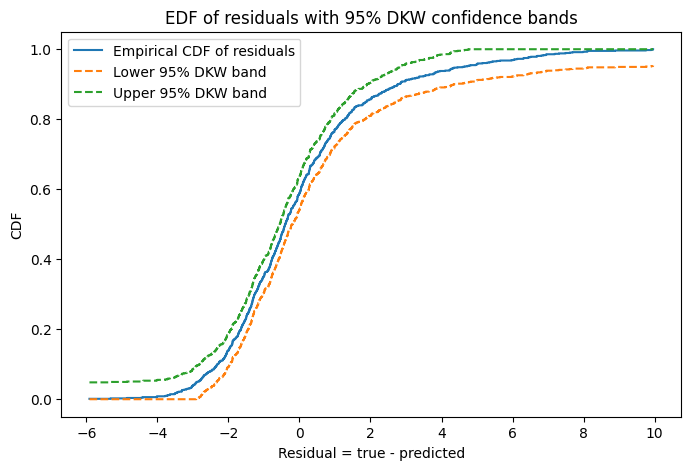

np.float64(0.0469709230918113)

In [14]:
# Part 4
# Plot empirical distribution function of residuals with 95% DKW confidence bands.

problem2_residuals = problem2_y_test.values - problem2_y_pred
residuals_sorted = np.sort(problem2_residuals)
n = len(residuals_sorted)

edf = np.arange(1, n + 1) / n

delta = 0.05
epsilon = np.sqrt(np.log(2 / delta) / (2 * n))

lower_band = np.maximum(edf - epsilon, 0)
upper_band = np.minimum(edf + epsilon, 1)

plt.figure(figsize=(8, 5))
plt.step(residuals_sorted, edf, where="post", label="Empirical CDF of residuals")
plt.step(residuals_sorted, lower_band, where="post", linestyle="--", label="Lower 95% DKW band")
plt.step(residuals_sorted, upper_band, where="post", linestyle="--", label="Upper 95% DKW band")
plt.xlabel("Residual = true - predicted")
plt.ylabel("CDF")
plt.title("EDF of residuals with 95% DKW confidence bands")
plt.legend()
plt.show()

epsilon

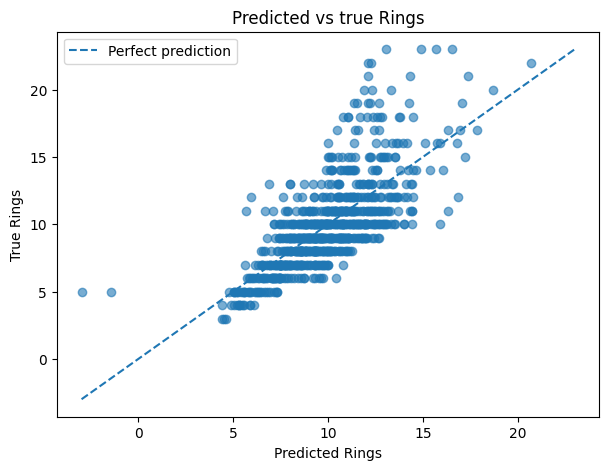

In [16]:
# Part 5
# Scatter plot: predicted values on x-axis, true values on y-axis.

plt.figure(figsize=(7, 5))
plt.scatter(problem2_y_pred, problem2_y_test, alpha=0.6)
min_val = min(problem2_y_pred.min(), problem2_y_test.min())
max_val = max(problem2_y_pred.max(), problem2_y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", label="Perfect prediction")
plt.xlabel("Predicted Rings")
plt.ylabel("True Rings")
plt.title("Predicted vs true Rings")
plt.legend()
plt.show()

### Problem 2 Part 6 — Free-text answer

The MAE tells us the average absolute error in number of rings. For example, if the MAE is around 1.5–2 rings, then the model is typically wrong by around 1.5–2 rings.

The predicted-vs-true scatter plot should ideally lie close to the diagonal line. If the points are widely scattered, then the model is not very accurate. A simple linear regression can capture some trend from physical measurements, but abalone age is not perfectly linear in those measurements, so some prediction error is expected.

The DKW confidence band gives uncertainty around the whole residual CDF. It can be used to estimate quantiles of prediction error and understand how large errors may be.

## Problem 3 — Full Question

Maximum Points = 13

A healthcare organization is interested in understanding the relationship between the number of visits to the doctor's office and certain patient characteristics. They collected data on the number of visits for a sample of patients and included the following variables:

- `ofp`: number of physician office visits
- `ofnp`: number of nonphysician office visits
- `opp`: number of physician outpatient visits
- `opnp`: number of nonphysician outpatient visits
- `emr`: number of emergency room visits
- `hosp`: number of hospitalizations
- `exclhlth`: the person is of excellent health (self-perceived)
- `poorhealth`: the person is of poor health (self-perceived)
- `numchron`: number of chronic conditions
- `adldiff`: the person has a condition that limits activities of daily living
- `noreast`: the person is from the north east region
- `midwest`: the person is from the midwest region
- `west`: the person is from the west region
- `age`: age in years divided by 10
- `male`: is the person male?
- `married`: is the person married?
- `school`: number of years of education
- `faminc`: family income in 10000$
- `employed`: is the person employed?
- `privins`: is the person covered by private health insurance?
- `medicaid`: is the person covered by medicaid?

Decide which patient features are reasonable to use to predict the target **number of physician office visits**. Hint: should we really use the `ofnp` etc variables?

Since the target variable is counts, a reasonable loss function is to consider the target variable as Poisson distributed where

\[
\lambda = \exp(\alpha\cdot x+\beta)
\]

where \(\alpha\) is a vector and \(\beta\) is the intercept. The conditional density is

\[
f_{Y|X}(y,x)=\frac{\lambda^y e^{-\lambda}}{y!},\qquad
\lambda(x)=\exp(\alpha\cdot x+\beta).
\]

When taking the log, the \(y!\) term does not depend on \(\lambda,\alpha,\beta\), so it can be discarded.

Instructions:

1. **[3p]** Load `data/visits_clean.csv` into `problem3_df`. Decide what should be features and target, give motivations.

2. **[3p]** Create `problem3_X` and `problem3_y` as numpy arrays. Do the train-test split with 80% training and 20% testing.

3. **[2p]** Implement `loss` inside the class `PoissonRegression`.

4. **[2p]** Use the `PoissonRegression` class to train a Poisson regression model on the training data.

5. **[3p]** Come up with a reasonable metric to evaluate your model on the test data, compute it, justify it, interpret your result and compare it to a naive model.

### Problem 3 Part 1 — Free-text answer

The target should be `ofp`, the number of physician office visits.

Reasonable features are patient characteristics available before the visit count outcome, such as:

- health indicators: `exclhlth`, `poorhealth`, `numchron`, `adldiff`
- demographic/location variables: `noreast`, `midwest`, `west`, `age`, `male`, `married`, `school`, `faminc`, `employed`
- insurance variables: `privins`, `medicaid`

I would **not** use `ofnp`, `opp`, `opnp`, `emr`, or `hosp` as features if the goal is to predict physician office visits from patient characteristics, because these are also healthcare-use outcome variables. They may leak information about the target and make the model less meaningful.

Additional useful features could include prior-year visits, diagnoses, medication use, distance to clinic, and more detailed socioeconomic information.

In [ ]:
# Problem 3 imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# Part 1
problem3_df = pd.read_csv("data/visits_clean.csv")
problem3_df.head()

In [ ]:
# Part 1
problem3_target = "ofp"

# Avoid leakage from other utilization/count outcome variables.
exclude_cols = ["ofp", "ofnp", "opp", "opnp", "emr", "hosp"]
problem3_features = [col for col in problem3_df.columns if col not in exclude_cols]

problem3_features, problem3_target

In [ ]:
# Part 2
problem3_X = problem3_df[problem3_features].values
problem3_y = problem3_df[problem3_target].values

problem3_X_train, problem3_X_test, problem3_y_train, problem3_y_test = train_test_split(
    problem3_X,
    problem3_y,
    train_size=0.8,
    random_state=42
)

problem3_X_train.shape, problem3_X_test.shape, problem3_y_train.shape, problem3_y_test.shape

In [ ]:
# Part 3
class PoissonRegression(object):
    def __init__(self):
        self.coeffs = None
        self.result = None

    def fit(self, X, Y):
        import numpy as np
        from scipy import optimize

        # Define the objective/cost/loss function we want to minimise.
        def loss(coeffs):
            # lambda = exp(alpha dot x + beta)
            # coeffs[:-1] are alpha, coeffs[-1] is beta.
            eta = np.dot(X, coeffs[:-1]) + coeffs[-1]

            # Clip eta to avoid numerical overflow in exp during optimization.
            eta = np.clip(eta, -20, 20)
            lam = np.exp(eta)

            # Negative log-likelihood ignoring log(y!) constant:
            # nll = lambda - y*log(lambda)
            # Since log(lambda)=eta:
            # nll = lambda - y*eta
            return float(np.mean(lam - Y * eta))

        initial_arguments = np.zeros(shape=X.shape[1] + 1)
        self.result = optimize.minimize(loss, initial_arguments, method="cg")
        self.coeffs = self.result.x

    def predict(self, X):
        if self.coeffs is not None:
            eta = np.dot(X, self.coeffs[:-1]) + self.coeffs[-1]
            eta = np.clip(eta, -20, 20)
            return np.exp(eta)
        else:
            raise ValueError("Model has not been fitted yet.")

In [ ]:
# Part 4
problem3_model = PoissonRegression()
problem3_model.fit(problem3_X_train, problem3_y_train)

# This should ideally show success=True.
print(problem3_model.result)

In [ ]:
# Part 5
# Use MAE as metric because visits are counts and MAE is easy to interpret:
# average absolute error in number of visits.

problem3_pred = problem3_model.predict(problem3_X_test)

problem3_metric = float(mean_absolute_error(problem3_y_test, problem3_pred))
problem3_rmse = float(np.sqrt(mean_squared_error(problem3_y_test, problem3_pred)))

# Naive baseline: always predict training mean count.
naive_pred = np.full_like(problem3_y_test, fill_value=np.mean(problem3_y_train), dtype=float)
problem3_naive_mae = float(mean_absolute_error(problem3_y_test, naive_pred))

print("Poisson regression MAE:", problem3_metric)
print("Poisson regression RMSE:", problem3_rmse)
print("Naive mean predictor MAE:", problem3_naive_mae)

plt.figure(figsize=(7, 5))
plt.scatter(problem3_pred, problem3_y_test, alpha=0.5)
min_val = min(problem3_pred.min(), problem3_y_test.min())
max_val = max(problem3_pred.max(), problem3_y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", label="Perfect prediction")
plt.xlabel("Predicted physician office visits")
plt.ylabel("True physician office visits")
plt.title("Poisson regression: predicted vs true")
plt.legend()
plt.show()

### Problem 3 Part 5 — Free-text answer

A reasonable metric is **Mean Absolute Error (MAE)** because it tells us the average absolute mistake in the number of physician office visits.

I compare the Poisson regression MAE with a naive baseline that always predicts the average number of visits from the training set.

- If the Poisson regression MAE is lower than the naive MAE, then the model improves over simply guessing the average.
- If it is similar or worse, then the chosen features/model are not adding much predictive value.

Because visit counts can be noisy and overdispersed, a simple Poisson model may not perfectly fit the data, but it is a reasonable first model for count-valued targets.

In [ ]:
# Final checks
assert isinstance(problem1_p1, float)
assert isinstance(problem1_p2, float)
assert isinstance(problem1_irreducible, bool)
assert isinstance(problem1_stationary, np.ndarray)
assert np.isclose(problem1_stationary.sum(), 1)
assert isinstance(problem1_ET, float)

assert isinstance(problem2_df, pd.DataFrame)
assert isinstance(problem2_features, list)
assert isinstance(problem2_target, str)
assert isinstance(problem2_mae, float)

assert isinstance(problem3_df, pd.DataFrame)
assert isinstance(problem3_features, list)
assert isinstance(problem3_target, str)
assert isinstance(problem3_metric, float)

print("All main variables have the expected formats.")